In [1]:
import numpy as np
import getdist.plots
import matplotlib.pyplot as plt
import yaml
import sys
import os

In [2]:
# switch to the main directory
os.chdir('/Users/s2265800/Desktop/GitHub/MGlensing')

In [13]:
with open("tutorials/params_names.yaml", "r") as file:
    params_dic = yaml.safe_load(file)

with open("ini_files/ini_data/params_data_hmcode.yaml", "r") as file:
    fiducials = yaml.safe_load(file)

In [4]:
def read_last_header_line(file_path):
    last_header = None
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            if line.startswith('#'):
                last_header = line.strip('#').strip()  
            else:
                break  

    if last_header:
        return last_header.split() 
    else:
        return []

In [9]:
file_paths = [ 'chains/runs/chain_3x2pt_lsst_y1_forecast_w0wacdm.txt'  #'chains/chain_3x2pt_lsst_y1_forecast_w0wacdm_first7cols.txt'
    ]  

In [10]:
n_samples = len(file_paths)
chains_info = {}
for i in range(n_samples):
    file_path = file_paths[i]  
    chain = np.genfromtxt(file_path)
    chain_pars = read_last_header_line(file_path)
    chain_pars = chain_pars[:-2]
    chains_info[i] = {}
    chains_info[i]['chain'] = chain
    chains_info[i]['pars'] = chain_pars


samples = []    
for i in range(n_samples):
    samples.append(
        getdist.MCSamples(samples = chains_info[i]['chain'][:,:len(chains_info[i]['pars'])],
                                    names = [i for i in chains_info[i]['pars']],
                                    weights=np.exp(chains_info[i]['chain'][:, -2]),
                                    labels = [params_dic[p]
                                                for p in chains_info[i]['pars']],
                                    settings={'smooth_scale_2D':0.35, 'smooth_scale_1D':0.35},
                                    ) 
    )


Removed no burn in


In [11]:
ModelPars = chains_info[0]['pars']

Text(3.5, 0.05, 'LSST Y1 data \n 3x2pt-analysis\n $\\ell^{\\rm WL, GC}_{\\rm max}=2000, 100$')

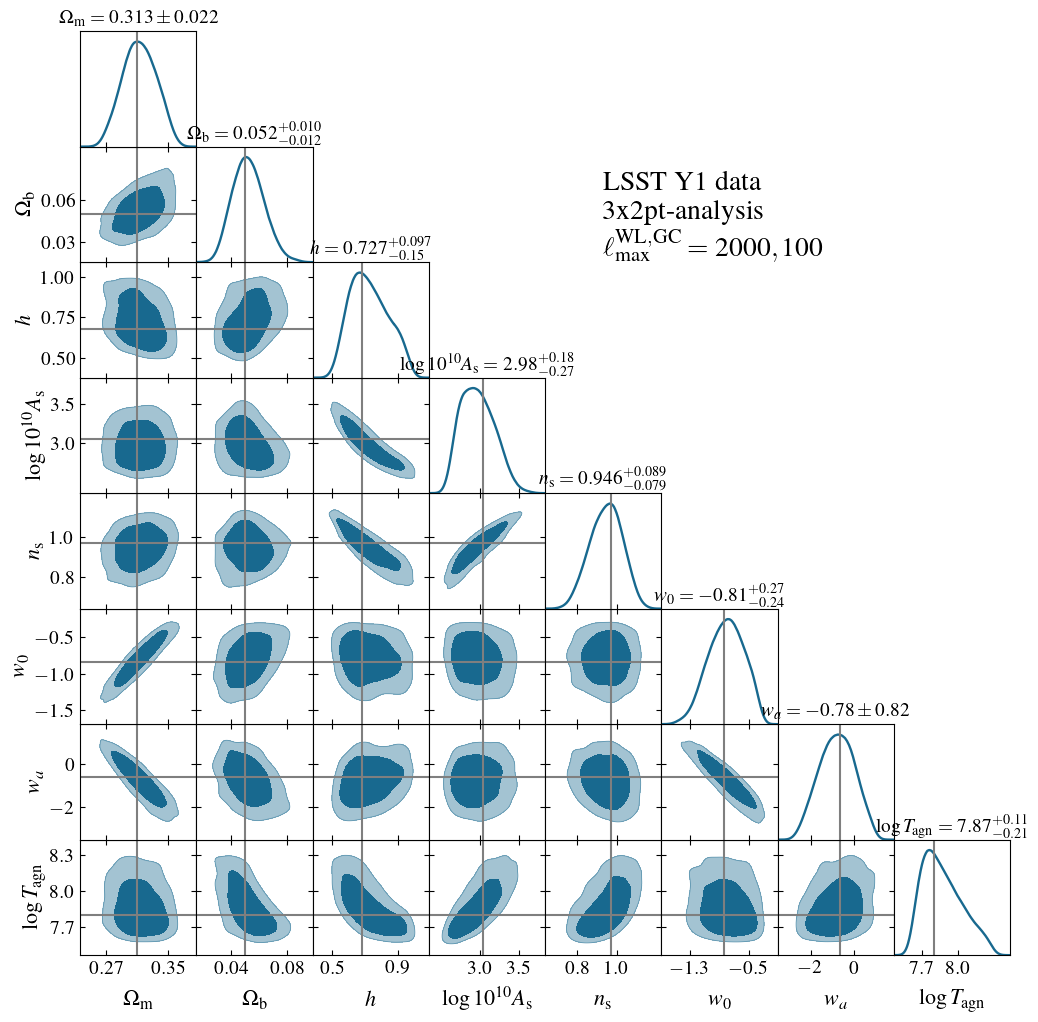

In [15]:
colors = [ '#18698F', '#7AC011', '#FF7083', '#99D4E5']
from matplotlib import rc
rc('text', usetex=True)
rc('font',**{'family':'serif','serif':['Times']})
g = getdist.plots.getSubplotPlotter(subplot_size=1.5)

plt.rcParams.update({'font.size':16})
g.settings.legend_fontsize=20
g.settings.axes_fontsize=18
g.settings.axes_labelsize=20
g.settings.linewidth=4   
g.settings.figure_legend_frame = False


ModelPars = ['Omega_m', 'Omega_b', 'h', 'log10As', 'ns', 'w0', 'wa', 'log10T_AGN']
legend_labels = []
g.triangle_plot(samples,
    ModelPars,
    legend_labels = legend_labels,
    title_limit=1,  # first title limit (for 1D plots) is 68% by default
    legend_loc = 'upper right',
    contour_args = [{'filled':True, 'color': colors[0]}, {'filled':True, 'color': colors[1], 'ls': '-'}, 
    {'filled':True, 'color': colors[2], 'ls': '-'},{'filled':False, 'color': colors[3], 'ls': '--'}], 
    line_args=[ {'color': colors[0], 'ls': '-'}, {'color': colors[1], 'ls': '-'}, 
    {'color': colors[2], 'ls': '-'}, {'color': colors[3], 'ls': '--'}])

if fiducials != None:
    for i in range(len(ModelPars)):
        for j in range(i+1):
            ax = g.subplots[i,j]
            if i != j and ModelPars[i] in fiducials and fiducials[ModelPars[i]] != None:
                ax.axhline(fiducials[ModelPars[i]],lw=1.5,color='tab:gray')
            if ModelPars[j] in fiducials and fiducials[ModelPars[j]] != None:
                ax.axvline(fiducials[ModelPars[j]],lw=1.5,color='tab:gray')

num = 1
ax = g.subplots[num, num]
annotation_text = 'LSST Y1 data \n 3x2pt-analysis\n $\ell^{\\rm WL, GC}_{\\rm max}=2000, 100$'
ax.annotate(annotation_text, (3.5, 0.05), xycoords='axes fraction', clip_on=False, fontsize=20)       